[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\numbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- Basic Metadata Statistics ---
            count       mean        std   min    25%   50%   75%    max
char_count  202.0  79.534653  18.035931  38.0  69.25  82.0  92.0  128.0
word_count  202.0  11.504950   3.058708   5.0   9.00  12.0  14.0   22.0


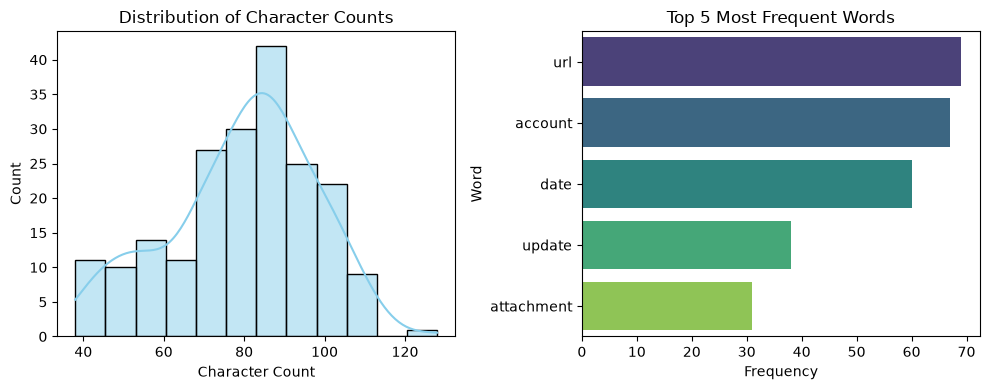


--- Top 3 Most Frequent Bigrams ---
attachment account: 8
account url: 7
url free: 7


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Setup Mock Dataset
df = pd.read_csv("../../data/silver/example_dataset.csv")

# 2. Text Metadata Extraction
# Calculate character length and word count per entry
df['char_count'] = df['Masked_Text'].apply(len)
df['word_count'] = df['Masked_Text'].apply(lambda x: len(x.split()))

print("--- Basic Metadata Statistics ---")
print(df[['char_count', 'word_count']].describe().T)

# 3. Text Preprocessing for Frequency Analysis
def clean_and_tokenize(text):
    # Convert to lowercase and tokenize words
    tokens = nltk.word_tokenize(text.lower())
    # Remove punctuation and English stop words
    stop_words = set(stopwords.words('english'))
    cleaned = [word for word in tokens if word.isalnum() and word not in stop_words]
    return cleaned

# Apply cleaning
df['cleaned_tokens'] = df['Masked_Text'].apply(clean_and_tokenize)

# Flatten list of all words across all documents
all_words = [word for tokens in df['cleaned_tokens'] for word in tokens]

# 4. Plot Top Unigrams (Most Common Individual Words)
word_counts = Counter(all_words)
top_words_df = pd.DataFrame(word_counts.most_common(5), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 4))

# Subplot 1: Distribution of Text Character Counts
plt.subplot(1, 2, 1)
sns.histplot(df['char_count'], kde=True, color='skyblue')
plt.title('Distribution of Character Counts')
plt.xlabel('Character Count')

# Subplot 2: Bar Plot of Top Words
plt.subplot(1, 2, 2)
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis', hue='Word', legend=False)
plt.title('Top 5 Most Frequent Words')

plt.tight_layout()
plt.show()

# 5. N-gram Analysis (Bigrams)
# Generate pairs of consecutive words to capture basic context
all_bigrams = list(ngrams(all_words, 2))
bigram_counts = Counter(all_bigrams)

print("\n--- Top 3 Most Frequent Bigrams ---")
for bigram, freq in bigram_counts.most_common(3):
    print(f"{bigram[0]} {bigram[1]}: {freq}")


In [4]:
df = pd.read_csv("../../data/gold/enriched_dataset.csv")

In [3]:
df

,Full_Text,Label,urgency_label,urgency_confidence,fear_label,fear_confidence,authority_label,authority_confidence,reciprocity_label,reciprocity_confidence,...,promotional_confidence,transactional_label,transactional_confidence,reminder_label,reminder_confidence,personal_label,personal_confidence,annotation_status,annotation_error,annotation_model
0,Subject: Office maintenance\n\nThanks for your...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,True,0.85,success,NaN,gemini-2.5-flash
1,"Hello, your profile has been locked. Use the s...",Malicious,True,0.75,True,0.80,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
2,"Hi there, congratulations! You are the winner ...",Malicious,True,0.95,False,0.00,True,0.80,True,0.95,...,0.95,False,0.0,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
3,"Attention, this is the fraud prevention accoun...",Malicious,True,0.90,True,0.95,True,0.95,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
4,"Notice, your profile has been restricted. Use ...",Malicious,True,0.75,True,0.80,True,0.90,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50783,contact number i can be reached at <PHONE_NUMB...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.8,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50784,"summer internship hi ,\ni ' d like to thank yo...",Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50785,terminated employees louise -\nthe following e...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50786,"enron / hpl actuals for july 17 , 2000 teco ta...",Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash


In [24]:
filtered = df[(df['Label'] == "Benign") & (df['pretexting_label'] == True)][["Full_Text", "Label", "pretexting_label"]]

display(filtered)

,Full_Text,Label,pretexting_label
5306,I'm e person who's doing e sms survey...,Benign,True
5435,Sorry about that this is my mates phone and i ...,Benign,True
5673,<PERSON> can u transfr me d amt,Benign,True
5762,Misplaced your number and was sending texts to...,Benign,True
5807,"Sir, I need <PERSON> sir's date of birth and c...",Benign,True
...,...,...,...
48934,eastrans nomination change effective 10 / 19 /...,Benign,True
49223,look at this - - it ' s important ! ! ! ! ! ok...,Benign,True
49516,"need deal for march 2000 <PERSON> ,\n<PERSON> ...",Benign,True
50281,"new pc with two 128 mb of <PERSON> ,\nis this ...",Benign,True


In [10]:
missing_annotations = df[(df['annotation_status'] == 'failed')][['Full_Text', 'Label']]

display(missing_annotations)

,Full_Text,Label
14800,"Make the Impossible, Possible. Enlarge your Pe...",Malicious
14801,Re: [opensuse] OpenSUSE's New Tech Evangelist ...,Benign
14802,<PERSON> watches from Officine Panerai closest...,Malicious
14803,No Pumps! No Surgery! No Exercises! \nBe the ...,Malicious
14804,How to make her your slave \nSmell better with...,Malicious
...,...,...
49745,"guadalupe power juneol hi <PERSON> ,\ni saw th...",Benign
49746,california prices have fun !,Benign
49747,onondaga accounting <PERSON> :\nin our meeting...,Benign
49748,request submitted : access request for <PERSON...,Benign


In [7]:
cleaned_df = df.dropna(subset=['urgency_label'])

display(cleaned_df)

,Full_Text,Label,urgency_label,urgency_confidence,fear_label,fear_confidence,authority_label,authority_confidence,reciprocity_label,reciprocity_confidence,...,promotional_confidence,transactional_label,transactional_confidence,reminder_label,reminder_confidence,personal_label,personal_confidence,annotation_status,annotation_error,annotation_model
0,Subject: Office maintenance\n\nThanks for your...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,True,0.85,success,NaN,gemini-2.5-flash
1,"Hello, your profile has been locked. Use the s...",Malicious,True,0.75,True,0.80,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
2,"Hi there, congratulations! You are the winner ...",Malicious,True,0.95,False,0.00,True,0.80,True,0.95,...,0.95,False,0.0,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
3,"Attention, this is the fraud prevention accoun...",Malicious,True,0.90,True,0.95,True,0.95,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
4,"Notice, your profile has been restricted. Use ...",Malicious,True,0.75,True,0.80,True,0.90,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50783,contact number i can be reached at <PHONE_NUMB...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.8,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50784,"summer internship hi ,\ni ' d like to thank yo...",Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50785,terminated employees louise -\nthe following e...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50786,"enron / hpl actuals for july 17 , 2000 teco ta...",Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.9,False,0.0,False,0.00,success,NaN,gemini-2.5-flash


In [11]:

missing_annotations.to_csv("../../data/silver/remaining_annotations.csv", index=False)



In [5]:
dataset_1 = pd.read_csv("../../data/gold/enriched_dataset.csv")
dataset_2 = pd.read_csv("../../data/gold/remaining_enriched_dataset.csv")

dataset_1 = dataset_1[dataset_1['annotation_status'] == 'success']
dataset_2 = dataset_2[dataset_2['annotation_status'] == 'success']

combined = pd.concat([dataset_1, dataset_2], ignore_index=True)

combined

,Full_Text,Label,urgency_label,urgency_confidence,fear_label,fear_confidence,authority_label,authority_confidence,reciprocity_label,reciprocity_confidence,...,promotional_confidence,transactional_label,transactional_confidence,reminder_label,reminder_confidence,personal_label,personal_confidence,annotation_status,annotation_error,annotation_model
0,Subject: Office maintenance\n\nThanks for your...,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.90,False,0.0,True,0.85,success,NaN,gemini-2.5-flash
1,"Hello, your profile has been locked. Use the s...",Malicious,True,0.75,True,0.80,False,0.00,False,0.00,...,0.00,True,0.90,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
2,"Hi there, congratulations! You are the winner ...",Malicious,True,0.95,False,0.00,True,0.80,True,0.95,...,0.95,False,0.00,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
3,"Attention, this is the fraud prevention accoun...",Malicious,True,0.90,True,0.95,True,0.95,False,0.00,...,0.00,True,0.90,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
4,"Notice, your profile has been restricted. Use ...",Malicious,True,0.75,True,0.80,True,0.90,False,0.00,...,0.00,True,0.90,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50723,"guadalupe power juneol hi <PERSON> ,\ni saw th...",Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,True,0.90,False,0.0,True,0.80,success,NaN,gemini-2.5-flash
50724,california prices have fun !,Benign,False,0.00,False,0.00,False,0.00,False,0.00,...,0.00,False,0.00,False,0.0,False,0.00,success,NaN,gemini-2.5-flash
50725,onondaga accounting <PERSON> :\nin our meeting...,Benign,False,0.00,False,0.00,True,0.70,False,0.00,...,0.00,True,0.80,False,0.0,True,0.80,success,NaN,gemini-2.5-flash
50726,request submitted : access request for <PERSON...,Benign,False,0.00,False,0.00,True,0.85,False,0.00,...,0.00,True,0.95,False,0.0,False,0.00,success,NaN,gemini-2.5-flash


In [6]:
combined.to_csv("../../data/gold/final_enriched_dataset.csv", index=False)